# **Modern Face Detection: YuNet (DNN) vs. Haar Cascades**

## **Objectives:**
1. Load a pretrained DNN face detector — `cv2.FaceDetectorYN` — the OpenCV team's own recommended replacement for Haar cascades
2. Compare it head-to-head against notebook 16's Haar cascade on the same photo
3. Find a case where Haar breaks and YuNet doesn't, and see why that's not a coincidence

> **Assets.** `assets/haarcascades/face_detection_yunet_2023mar.onnx` is Yu Shiqi's YuNet model, redistributed by OpenCV's own model zoo ([opencv/opencv_zoo](https://github.com/opencv/opencv_zoo/tree/main/models/face_detection_yunet), MIT-licensed — that model directory carries its own explicit `LICENSE` file). There are newer exports in the same directory (`..._2026may.onnx`), but that one uses a *dynamic* input shape meant for OpenCV 5.x's ONNX Runtime engine; the `2023mar` fixed-shape build is the one that actually works cleanly with this repo's pinned `opencv-python-headless==4.10.0.84` DNN module — worth knowing before grabbing "the newest one" by name alone.

## **Why this notebook exists**

This repo's `requirements.txt` has been pinned to `opencv-python-headless==4.10.0.84` since notebook 16 was first built, because the 5.0.0 headless wheel available at the time shipped without `cv2.CascadeClassifier` at all. It turns out that's not a packaging bug — [OpenCV's own 4→5 migration notes](https://github.com/opencv/opencv/wiki/OpenCV-4-to-5-migration) say plainly that Haar cascades moved to the separate `opencv_contrib` `xobjdetect` module in 5.x, with **DNN-based face detection recommended as the replacement**. So notebook 16 staying on 4.10.x isn't a temporary workaround waiting for a patch — it's the classical/legacy path, on purpose. This notebook is that recommended replacement, run side by side with the classifier it's meant to replace.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Loading both detectors**

`cv2.FaceDetectorYN_create(model_path, config_path, input_size, score_threshold, nms_threshold, top_k)` — `config_path` is only needed for Caffe/TensorFlow models, left empty for ONNX. `input_size` has to match the image you're detecting on (call `detector.setInputSize(...)` again if the image size changes). Where Haar's `detectMultiScale` returns just `(x, y, w, h)` boxes, YuNet's `detect()` returns 15 numbers per face: the box, then 5 facial landmarks (right eye, left eye, nose tip, right mouth corner, left mouth corner) as x,y pairs, then a confidence score — a single forward pass gets you landmarks for free, something Haar cascades were never built to provide.

In [2]:
image = cv2.imread('assets/images/lena.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
h, w = image.shape[:2]

face_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_frontalface_default.xml')
yunet = cv2.FaceDetectorYN_create(
    'assets/haarcascades/face_detection_yunet_2023mar.onnx', '', (w, h),
    score_threshold=0.6, nms_threshold=0.3, top_k=5000,
)

haar_faces = face_classifier.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
_, yunet_faces = yunet.detect(image)

print(f'Haar found {len(haar_faces)} face(s)')
print(f'YuNet found {0 if yunet_faces is None else len(yunet_faces)} face(s)')

Haar found 1 face(s)
YuNet found 1 face(s)


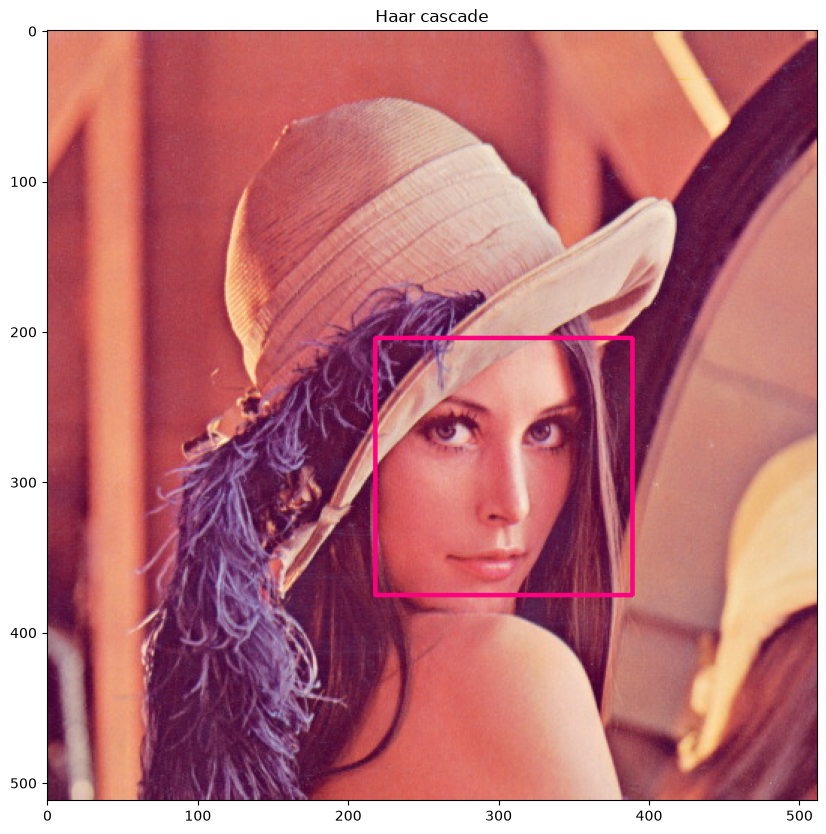

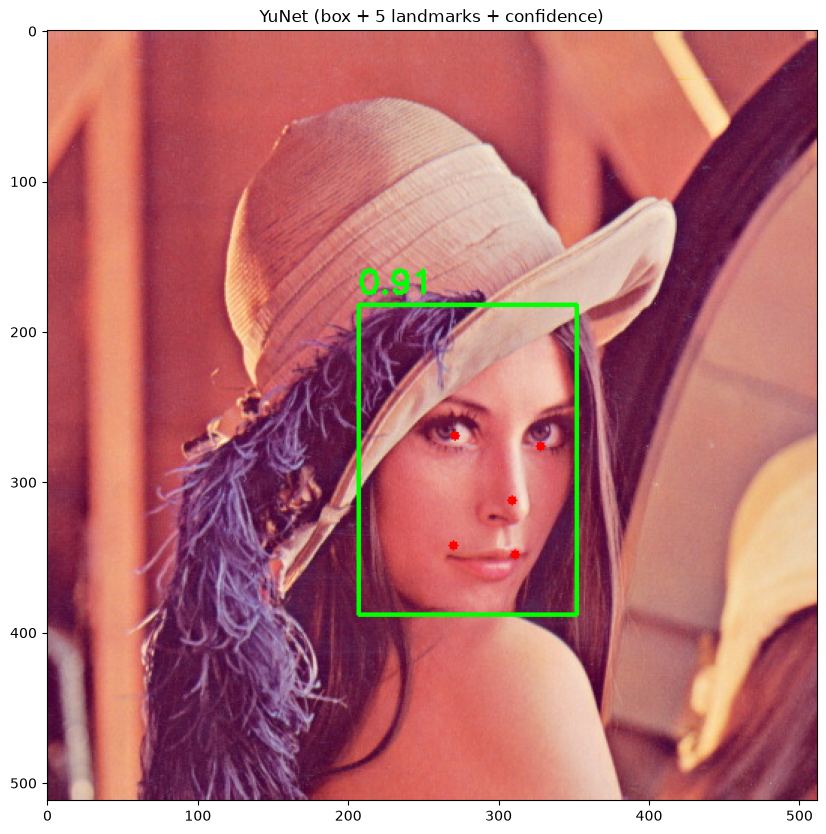

In [3]:
haar_vis = image.copy()
for (x, y, fw, fh) in haar_faces:
    cv2.rectangle(haar_vis, (x, y), (x + fw, y + fh), (127, 0, 255), 2)
imshow('Haar cascade', haar_vis)

yunet_vis = image.copy()
if yunet_faces is not None:
    for face in yunet_faces:
        box = face[:4].astype(int)
        landmarks = face[4:14].reshape(5, 2).astype(int)
        score = face[14]
        cv2.rectangle(yunet_vis, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), (0, 255, 0), 2)
        for (lx, ly) in landmarks:
            cv2.circle(yunet_vis, (lx, ly), 3, (0, 0, 255), -1)
        cv2.putText(yunet_vis, f'{score:.2f}', (box[0], box[1] - 8),
                     cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
imshow('YuNet (box + 5 landmarks + confidence)', yunet_vis)

## **Where Haar actually breaks: rotation**

Haar cascades are trained on axis-aligned, upright faces — the classifier's cascade of rectangular features simply doesn't match a face tilted 30-40°. YuNet, trained end-to-end on the WIDER Face dataset (which includes faces at every real-world angle), doesn't have that limitation. This isn't a cherry-picked edge case — camera-tilt or a tilted head is completely ordinary, and it's one of the most commonly cited reasons production systems moved off Haar cascades well before OpenCV made it official.

Haar on a 35 degree tilted face: 0 found
YuNet on a 35 degree tilted face: 1 found


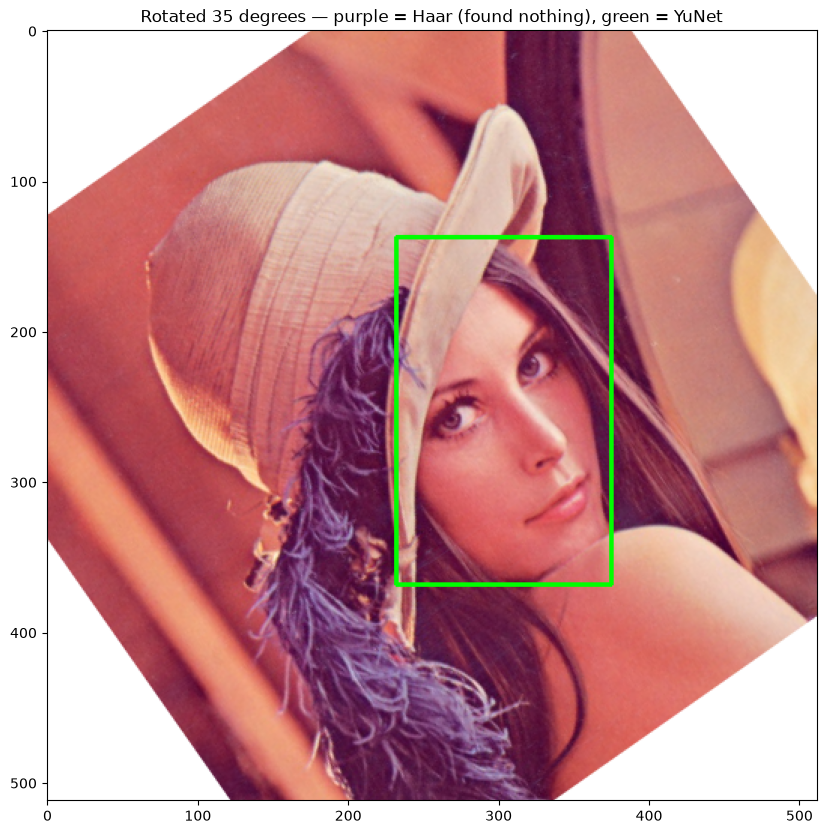

In [4]:
angle = 35
M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
rotated = cv2.warpAffine(image, M, (w, h), borderValue=(255, 255, 255))
rotated_gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)

haar_on_rotated = face_classifier.detectMultiScale(rotated_gray, scaleFactor=1.3, minNeighbors=5)
yunet.setInputSize((w, h))
_, yunet_on_rotated = yunet.detect(rotated)

print(f'Haar on a {angle} degree tilted face: {len(haar_on_rotated)} found')
print(f'YuNet on a {angle} degree tilted face: '
      f'{0 if yunet_on_rotated is None else len(yunet_on_rotated)} found')

vis = rotated.copy()
for (x, y, fw, fh) in haar_on_rotated:
    cv2.rectangle(vis, (x, y), (x + fw, y + fh), (127, 0, 255), 2)
if yunet_on_rotated is not None:
    for face in yunet_on_rotated:
        box = face[:4].astype(int)
        cv2.rectangle(vis, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), (0, 255, 0), 2)
imshow(f'Rotated {angle} degrees — purple = Haar (found nothing), green = YuNet', vis)

## **Speed: not the tradeoff you might expect**

The intuition "classical is fast, DNN is slow" doesn't hold here — YuNet is a genuinely lightweight, purpose-built architecture (that's the *tiny* in its training scheme's design goal), while Haar's cascade has to slide windows across many scales. On a small single-portrait image like this one they're roughly comparable, sometimes with YuNet ahead — measure it yourself below rather than trusting either intuition; the actual numbers depend on image size and hardware.

In [5]:
import time

N = 20
t0 = time.perf_counter()
for _ in range(N):
    face_classifier.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
t1 = time.perf_counter()
yunet.setInputSize((w, h))
for _ in range(N):
    yunet.detect(image)
t2 = time.perf_counter()

print(f'Haar:  {(t1 - t0) / N * 1000:.2f} ms/image')
print(f'YuNet: {(t2 - t1) / N * 1000:.2f} ms/image')

Haar:  3.58 ms/image
YuNet: 4.76 ms/image


### Where to go from here

- Sweep `score_threshold` from 0.2 to 0.9 and plot how many (real vs. spurious) detections survive — this is the same precision/recall tradeoff `SimpleBlobDetector`'s params exposed back in notebook 13, just for a neural detector instead.
- Swap `cv2.imread('assets/images/lena.jpg')` for a live webcam frame the same way notebook 16 does, and run both detectors per-frame — YuNet's landmark points are enough to build a basic eye-tracker without ever touching a separate eye cascade.
- `face_detection_yunet_2023mar_int8bq.onnx` (same directory in opencv_zoo, also MIT) is a block-quantized version — swap it in and compare both speed and the confidence scores against the full-precision model.